En este scripts, vamos a predecir el redshift utilizando 
una regresión simple con el Modelo de Random Forest.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))
from preprocess_vae import load_features

In [14]:
df = load_features()

Filtros de catálogo:
  inicial            : 29575
  maskbits==0        : 27757
  flujo>0 (griz)     : 26166
  profundidad (mag)  : 21340
  SNR>=3 (griz)      : 21287


In [15]:
df.columns

Index(['desi_id', 'mean_fiber_ra', 'mean_fiber_dec', 'z', 'zerr', 'ra', 'dec',
       'type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'ebv', 'brickid',
       'dchisq_psf', 'dchisq_rex', 'dchisq_exp', 'dchisq_dev', 'dchisq_ser',
       'id', 'flux_g', 'flux_r', 'flux_i', 'flux_z', 'flux_w1', 'flux_w2',
       'flux_w3', 'flux_w4', 'flux_ivar_g', 'flux_ivar_r', 'flux_ivar_i',
       'flux_ivar_z', 'flux_ivar_w1', 'flux_ivar_w2', 'flux_ivar_w3',
       'flux_ivar_w4', 'mw_transmission_i', 'fitbits', 'mw_transmission_w1',
       'brickname', 'mw_transmission_z', 'mw_transmission_g', 'maskbits',
       'mw_transmission_w2', 'mw_transmission_w3', 'objid',
       'mw_transmission_w4', 'mw_transmission_r', 'mag_g_corr', 'mag_r_corr',
       'mag_i_corr', 'mag_z_corr', 'SNR_g', 'SNR_r', 'SNR_i', 'SNR_z'],
      dtype='str')

In [16]:
df['mag_w1_corr'] = df['flux_w1']/df['mw_transmission_w1']
df['mag_w2_corr'] = df['flux_w2']/df['mw_transmission_w2']
df['mag_w3_corr'] = df['flux_w3']/df['mw_transmission_w3']
df['mag_w4_corr'] = df['flux_w4']/df['mw_transmission_w4']

In [17]:
df = df[['type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', "mag_g_corr", "mag_r_corr", "mag_i_corr", "mag_z_corr", "mag_w1_corr", "mag_w2_corr", "mag_w3_corr", "mag_w4_corr",'z']]
df.dropna(inplace=True)
X = df.drop(columns=['z'])
y = df['z']

In [18]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [19]:
def compute_photoz_metrics(z_true, z_pred, threshold=0.05, label=None):
    """Métricas estándar de photo-z: residuos normalizados, sigma_MAD y tasa de outliers catastróficos."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    # Residuo normalizado: Δz = (z_pred - z_true) / (1 + z_true)
    delta_z = (z_pred - z_true) / (1 + z_true)

    bias = delta_z.mean()
    std = delta_z.std()
    sigma_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
    eta = (np.abs(delta_z) > threshold).mean() * 100

    if label:
        print(f"--- Métricas photo-z: {label} ---")
    print(f"<Δz> (bias)              = {bias:.5f}")
    print(f"std(Δz)                  = {std:.5f}")
    print(f"σ_MAD                    = {sigma_mad:.5f}")
    print(f"η [%] (|Δz| > {threshold})     = {eta:.3f}")

    return {"delta_z": delta_z, "bias": bias, "std": std, "sigma_mad": sigma_mad, "eta": eta}


def plot_specz_vs_photoz(z_true, z_pred, threshold=0.05, title=None, ax=None):
    """Scatter z_spec vs z_phot con línea 1:1 (punteada) y límites de error catastrófico (rojo, lw=5)."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(z_true, z_pred, alpha=0.4, s=4)

    lo = min(z_true.min(), z_pred.min())
    hi = max(z_true.max(), z_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=2, label="1:1")

    z_line = np.linspace(lo, hi, 200)
    ax.plot(z_line, z_line + threshold * (1 + z_line), color="red", lw=2,
            label=f"Límite error catastrófico (|Δz| > {threshold})")
    ax.plot(z_line, z_line - threshold * (1 + z_line), color="red", lw=2)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Redshift espectroscópico")
    ax.set_ylabel("Redshift fotométrico predicho")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

    return ax

In [20]:
# Considerando el problema como regresión

X = X.copy()
y = df["z"].copy()

numeric_features = [c for c in X.columns if c != "type"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=124
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=10,
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Residuos normalizados, σ_MAD y η
reg_metrics_v1 = compute_photoz_metrics(y_test.to_numpy(), y_pred, label="Regresión (sin colores)")

MAE:  0.0841
RMSE: 0.1504
R2:   0.8549
--- Métricas photo-z: Regresión (sin colores) ---
<Δz> (bias)              = 0.00719
std(Δz)                  = 0.10147
σ_MAD                    = 0.04639
η [%] (|Δz| > 0.05)     = 31.775


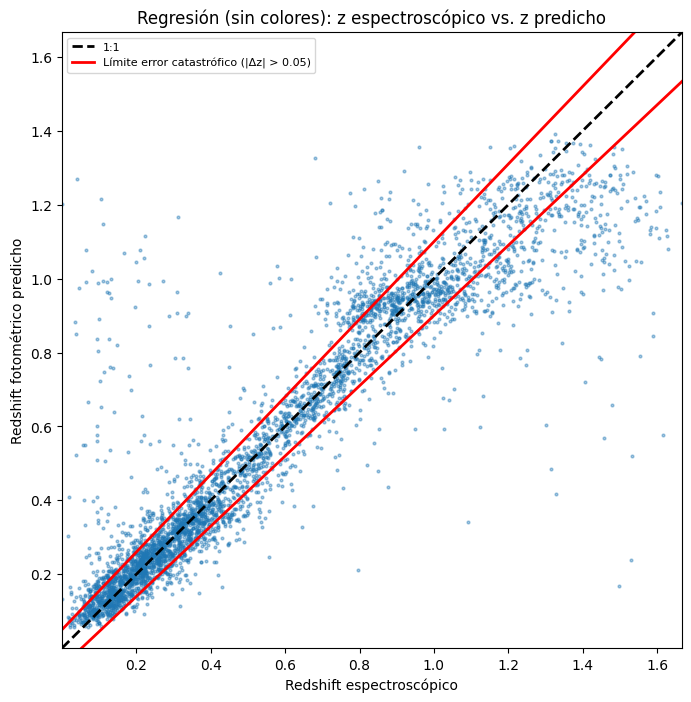

In [21]:
plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred,
    threshold=0.05,
    title="Regresión (sin colores): z espectroscópico vs. z predicho"
)
plt.show()

In [22]:
## Optimización de hiperparámetros
import optuna
from sklearn.model_selection import cross_val_score

# Optimización de hiperparámetros con Optuna (métrica: MSE)

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1,
        ))
    ])

    scores = cross_val_score(
        model, X_train, y_train,
        scoring="neg_mean_squared_error",
        cv=5,
        n_jobs=-1,
    )
    return -scores.mean()  # Optuna minimiza, y cross_val_score devuelve neg MSE



In [12]:
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Mejores hiperparámetros:", study.best_params)
print(f"Mejor MSE (CV): {study.best_value:.4f}")

# Entrenamiento final con los hiperparámetros optimizados
best_params = study.best_params

model_opt = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(**best_params, random_state=42, n_jobs=-1))
])

model_opt.fit(X_train, y_train)
y_pred_opt = model_opt.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_opt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2 = r2_score(y_test, y_pred_opt)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Residuos normalizados, σ_MAD y η
reg_metrics_opt = compute_photoz_metrics(y_test.to_numpy(), y_pred_opt, label="Regresión optimizada (Optuna)")

[I 2026-07-01 10:14:51,606] A new study created in memory with name: no-name-4bca2d69-ec45-4c38-aa23-b7048769faf7
Best trial: 0. Best value: 0.0239641:   2%|▏         | 1/50 [00:09<07:48,  9.57s/it]

[I 2026-07-01 10:15:01,172] Trial 0 finished with value: 0.023964124080507465 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.023964124080507465.


Best trial: 1. Best value: 0.0224442:   4%|▍         | 2/50 [00:24<09:59, 12.49s/it]

[I 2026-07-01 10:15:15,714] Trial 1 finished with value: 0.022444204404408093 and parameters: {'n_estimators': 447, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.022444204404408093.


Best trial: 1. Best value: 0.0224442:   6%|▌         | 3/50 [00:37<09:59, 12.76s/it]

...

[I 2026-07-01 10:34:39,073] Trial 47 finished with value: 0.02203966992425142 and parameters: {'n_estimators': 231, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 26 with value: 0.020929338581182587.


Best trial: 26. Best value: 0.0209293:  98%|█████████▊| 49/50 [20:00<00:22, 22.47s/it]

[I 2026-07-01 10:34:52,053] Trial 48 finished with value: 0.02242272465239604 and parameters: {'n_estimators': 325, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 26 with value: 0.020929338581182587.


Best trial: 26. Best value: 0.0209293: 100%|██████████| 50/50 [20:25<00:00, 24.50s/it]


[I 2026-07-01 10:35:16,766] Trial 49 finished with value: 0.026402309077125163 and parameters: {'n_estimators': 349, 'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': None}. Best is trial 26 with value: 0.020929338581182587.
Mejores hiperparámetros: {'n_estimators': 325, 'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None}
Mejor MSE (CV): 0.0209
MAE:  0.0774
RMSE: 0.1448
R2:   0.8656
--- Métricas photo-z: Regresión optimizada (Optuna) ---
<Δz> (bias)              = 0.00664
std(Δz)                  = 0.09751
σ_MAD                    = 0.03973
η [%] (|Δz| > 0.05)     = 26.703


In [23]:
# Mejores hiperparámetros

best_params = {'n_estimators': 325, 
               'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None}

model_opt = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(**best_params, random_state=42, n_jobs=-1))
])

model_opt.fit(X_train, y_train)
y_pred_opt = model_opt.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_opt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2 = r2_score(y_test, y_pred_opt)

reg_metrics_opt = compute_photoz_metrics(y_test.to_numpy(), y_pred_opt, label="Regresión optimizada (Optuna)")

--- Métricas photo-z: Regresión optimizada (Optuna) ---
<Δz> (bias)              = 0.00664
std(Δz)                  = 0.09751
σ_MAD                    = 0.03973
η [%] (|Δz| > 0.05)     = 26.703


In [26]:
print(f"mae: {mae}")
print(f"rmse : {rmse}")
print(f" MSE : {mean_squared_error(y_test, y_pred_opt)}")
print(f"r2 {r2}")

mae: 0.07735696208776972
rmse : 0.14480955668474246
 MSE : 0.02096980770723164
r2 0.8655568368780371


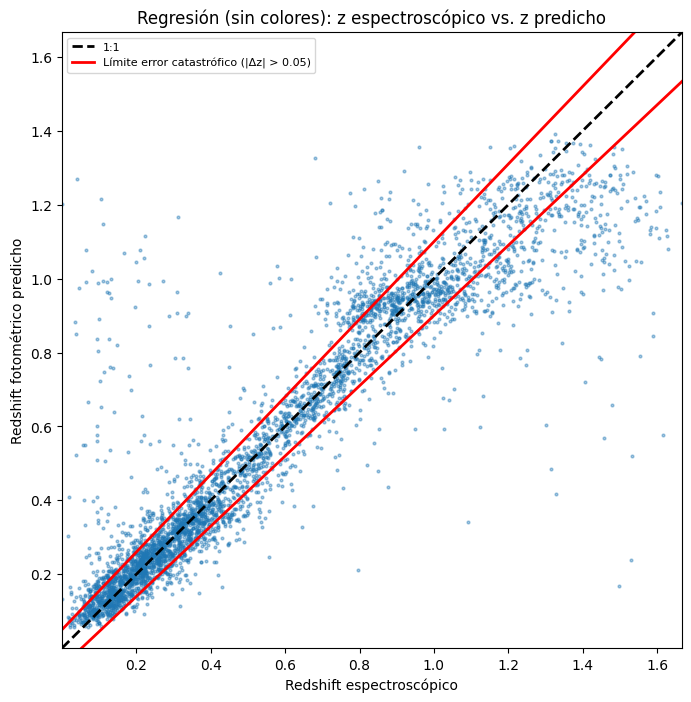

In [24]:
plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred,
    threshold=0.05,
    title="Regresión (sin colores): z espectroscópico vs. z predicho"
)
plt.show()

## Interpretabilidad


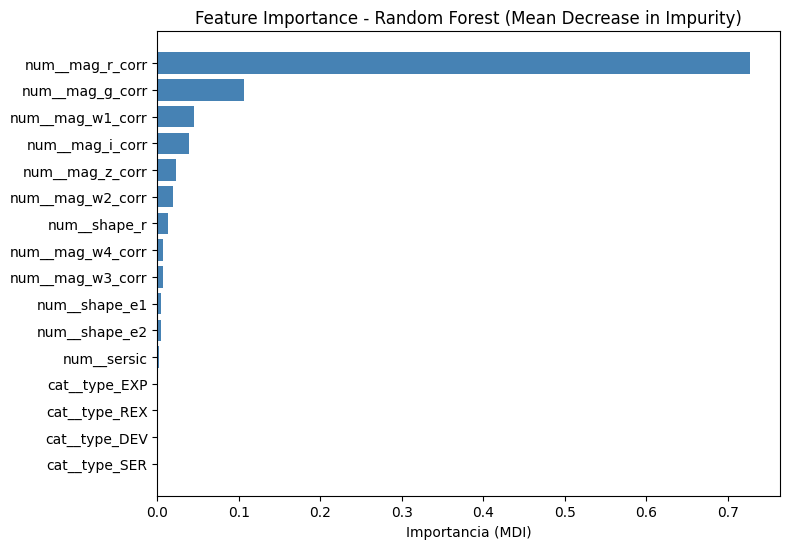

,feature,importance
5,num__mag_r_corr,0.727935
4,num__mag_g_corr,0.105979
8,num__mag_w1_corr,0.044772
6,num__mag_i_corr,0.039246
7,num__mag_z_corr,0.022980
9,num__mag_w2_corr,0.018929
0,num__shape_r,0.013140
11,num__mag_w4_corr,0.007071
10,num__mag_w3_corr,0.006823
1,num__shape_e1,0.004731


In [27]:
# --- Interpretabilidad: Feature Importance (MDI) ---

# Nombres de features tras el preprocesamiento (numéricas + one-hot de "type")
feature_names_out = model_opt.named_steps["preprocessor"].get_feature_names_out()

importances_mdi = model_opt.named_steps["regressor"].feature_importances_

imp_mdi_df = pd.DataFrame({
    "feature": feature_names_out,
    "importance": importances_mdi
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(imp_mdi_df))))
plt.barh(imp_mdi_df["feature"], imp_mdi_df["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importancia (MDI)")
plt.title("Feature Importance - Random Forest (Mean Decrease in Impurity)")
plt.tight_layout()
plt.show()

imp_mdi_df

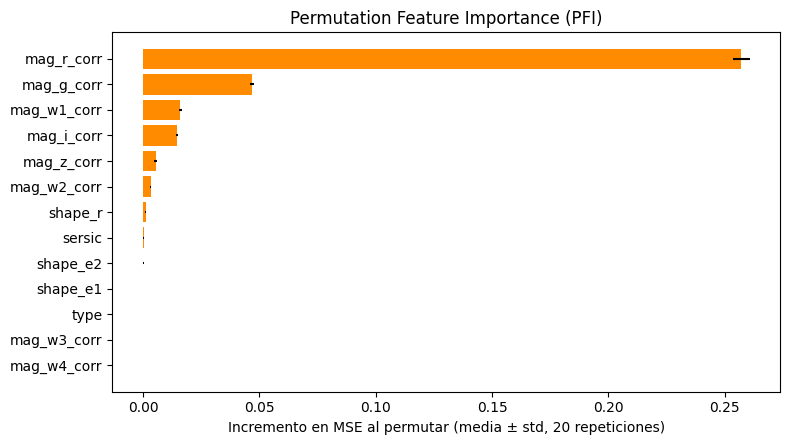

,feature,importance_mean,importance_std
6,mag_r_corr,0.257099,0.003551
5,mag_g_corr,0.046799,0.000942
9,mag_w1_corr,0.016059,0.000547
7,mag_i_corr,0.014568,0.000442
8,mag_z_corr,0.005445,0.000559
10,mag_w2_corr,0.003237,0.000240
1,shape_r,0.001126,0.000146
4,sersic,0.000294,0.000099
3,shape_e2,0.000177,0.000047
2,shape_e1,0.000145,0.000040


In [28]:
# --- Interpretabilidad: Permutation Feature Importance (PFI) ---
from sklearn.inspection import permutation_importance

# Se calcula sobre el pipeline completo (preprocessor + regressor) y el set de test,
# usando neg_mean_squared_error como métrica base (consistente con la optimización)
pfi_result = permutation_importance(
    model_opt,
    X_test,
    y_test,
    scoring="neg_mean_squared_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

pfi_df = pd.DataFrame({
    "feature": X_test.columns,  # PFI se calcula sobre features de entrada, no las post-OHE
    "importance_mean": pfi_result.importances_mean,
    "importance_std": pfi_result.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(pfi_df))))
plt.barh(
    pfi_df["feature"],
    pfi_df["importance_mean"],
    xerr=pfi_df["importance_std"],
    color="darkorange",
)
plt.gca().invert_yaxis()
plt.xlabel("Incremento en MSE al permutar (media ± std, 20 repeticiones)")
plt.title("Permutation Feature Importance (PFI)")
plt.tight_layout()
plt.show()

pfi_df

In [29]:
# --- Comparación MDI vs PFI ---

# Nota: MDI está a nivel de columnas post-OHE (ej: type_agn, type_star, ...),
# mientras que PFI está a nivel de columnas originales (type completo).
# Para comparar de forma justa, agregamos MDI de "type_*" sumando sus importancias.

imp_mdi_grouped = imp_mdi_df.copy()
imp_mdi_grouped["feature_original"] = imp_mdi_grouped["feature"].str.replace(
    r"^(num__|cat__)", "", regex=True
).str.replace(r"^type_.*", "type", regex=True)

imp_mdi_grouped = imp_mdi_grouped.groupby("feature_original")["importance"].sum().reset_index()
imp_mdi_grouped = imp_mdi_grouped.rename(columns={"feature_original": "feature"})

comparison = imp_mdi_grouped.merge(
    pfi_df[["feature", "importance_mean"]], on="feature", how="outer"
).rename(columns={"importance": "importance_mdi", "importance_mean": "importance_pfi"})

comparison = comparison.sort_values("importance_pfi", ascending=False)
comparison

,feature,importance_mdi,importance_pfi
2,mag_r_corr,0.727935,0.257099
0,mag_g_corr,0.105979,0.046799
3,mag_w1_corr,0.044772,0.016059
1,mag_i_corr,0.039246,0.014568
7,mag_z_corr,0.022980,0.005445
4,mag_w2_corr,0.018929,0.003237
11,shape_r,0.013140,0.001126
8,sersic,0.002134,0.000294
10,shape_e2,0.004514,0.000177
9,shape_e1,0.004731,0.000145


In [30]:
# Colores a partir de magnitudes corregidas
color_pairs = [
    ("g", "i"),
    ("g", "r"),
    ("r", "i"),
    ("i", "z"),
    ("z", "w1"),
    ("w1", "w2"),
    ("w2", "w3"),
    ("w3", "w4"),
]

for b1, b2 in color_pairs:
    X[f"color_{b1}{b2}"] = X[f"mag_{b1}_corr"] - X[f"mag_{b2}_corr"]


In [32]:
X.columns

Index(['type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'mag_g_corr',
       'mag_r_corr', 'mag_i_corr', 'mag_z_corr', 'mag_w1_corr', 'mag_w2_corr',
       'mag_w3_corr', 'mag_w4_corr', 'color_gi', 'color_gr', 'color_ri',
       'color_iz', 'color_zw1', 'color_w1w2', 'color_w2w3', 'color_w3w4'],
      dtype='str')

In [33]:
X.drop(columns=['type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic'], inplace=True)

In [35]:
# Considerando el problema como regresión

X = X.copy()
y = df["z"].copy()

numeric_features = [c for c in X.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=124
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=10,
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Residuos normalizados, σ_MAD y η
reg_metrics_v1 = compute_photoz_metrics(y_test.to_numpy(), y_pred, label="Regresión (con colores)")

MAE:  0.0740
RMSE: 0.1417
R2:   0.8712
--- Métricas photo-z: Regresión (con colores) ---
<Δz> (bias)              = 0.00562
std(Δz)                  = 0.09402
σ_MAD                    = 0.03791
η [%] (|Δz| > 0.05)     = 25.787


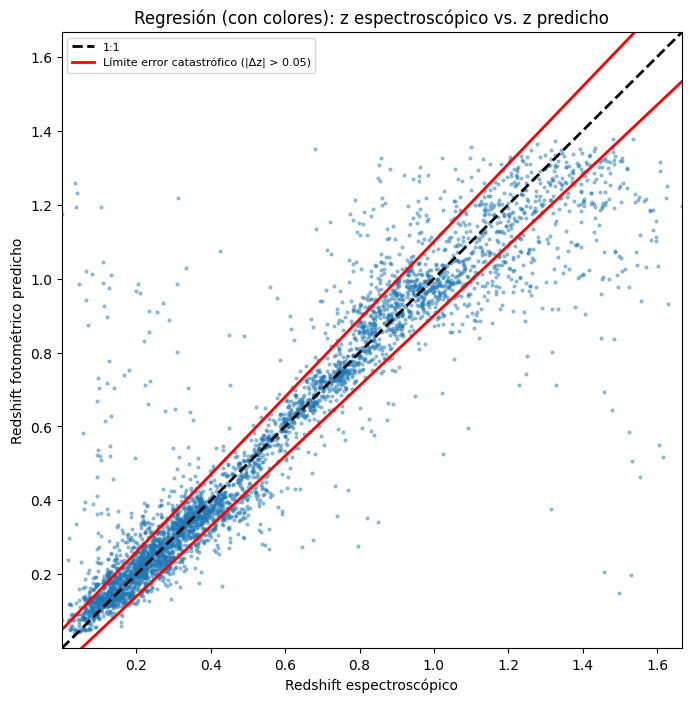

In [37]:
plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred,
    threshold=0.05,
    title="Regresión (con colores): z espectroscópico vs. z predicho"
)
plt.show()

In [38]:
# Optimización de hiperparámetros con Optuna (métrica: MSE)

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1,
        ))
    ])

    scores = cross_val_score(
        model, X_train, y_train,
        scoring="neg_mean_squared_error",
        cv=5,
        n_jobs=-1,
    )
    return -scores.mean()  # Optuna minimiza, y cross_val_score devuelve neg MSE

In [39]:
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Mejores hiperparámetros:", study.best_params)
print(f"Mejor MSE (CV): {study.best_value:.4f}")

# Entrenamiento final con los hiperparámetros optimizados
best_params = study.best_params

model_opt = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(**best_params, random_state=42, n_jobs=-1))
])

model_opt.fit(X_train, y_train)
y_pred_opt = model_opt.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_opt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2 = r2_score(y_test, y_pred_opt)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Residuos normalizados, σ_MAD y η
reg_metrics_opt = compute_photoz_metrics(y_test.to_numpy(), y_pred_opt, label="Regresión optimizada (Optuna)")

[I 2026-07-01 11:13:55,172] A new study created in memory with name: no-name-7a9e759e-4fcc-45d5-bf42-47217ee9d09f
Best trial: 0. Best value: 0.0200705:   2%|▏         | 1/50 [00:11<09:23, 11.50s/it]

[I 2026-07-01 11:14:06,675] Trial 0 finished with value: 0.020070491404733302 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.020070491404733302.


Best trial: 1. Best value: 0.0192235:   4%|▍         | 2/50 [00:31<13:06, 16.39s/it]

[I 2026-07-01 11:14:26,484] Trial 1 finished with value: 0.019223488144450247 and parameters: {'n_estimators': 447, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.019223488144450247.


Best trial: 1. Best value: 0.0192235:   6%|▌         | 3/50 [00:49<13:33, 17.31s/it]

...

[I 2026-07-01 11:29:47,996] Trial 47 finished with value: 0.01894136949672228 and parameters: {'n_estimators': 499, 'max_depth': 23, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 47 with value: 0.01894136949672228.


Best trial: 47. Best value: 0.0189414:  98%|█████████▊| 49/50 [16:54<00:48, 48.11s/it]

[I 2026-07-01 11:30:50,127] Trial 48 finished with value: 0.018960892638776868 and parameters: {'n_estimators': 493, 'max_depth': 29, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 47 with value: 0.01894136949672228.


Best trial: 47. Best value: 0.0189414: 100%|██████████| 50/50 [17:59<00:00, 21.58s/it]


[I 2026-07-01 11:31:54,173] Trial 49 finished with value: 0.01902345636808852 and parameters: {'n_estimators': 500, 'max_depth': 30, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 47 with value: 0.01894136949672228.
Mejores hiperparámetros: {'n_estimators': 499, 'max_depth': 23, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': None}
Mejor MSE (CV): 0.0189
MAE:  0.0701
RMSE: 0.1391
R2:   0.8759
--- Métricas photo-z: Regresión optimizada (Optuna) ---
<Δz> (bias)              = 0.00538
std(Δz)                  = 0.09229
σ_MAD                    = 0.03313
η [%] (|Δz| > 0.05)     = 22.358


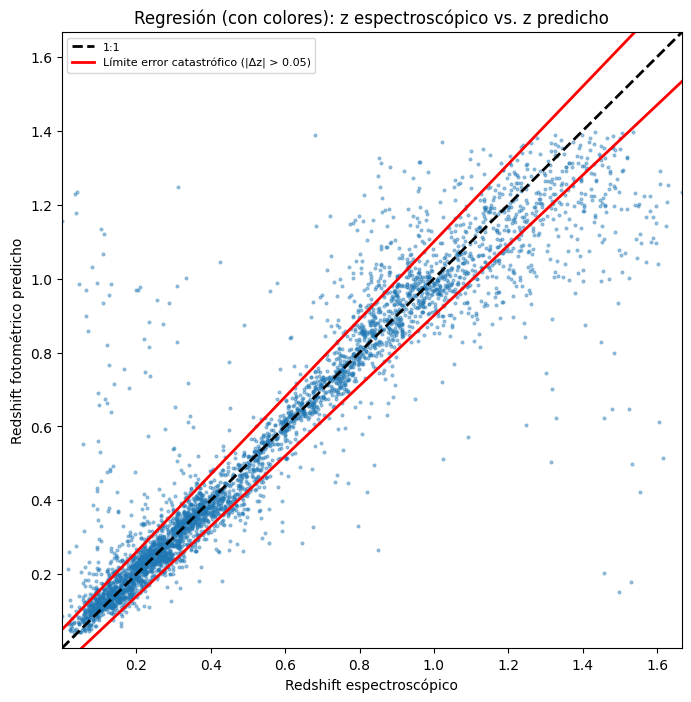

In [42]:
plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred_opt,
    threshold=0.05,
    title="Regresión (con colores): z espectroscópico vs. z predicho"
)
plt.show()

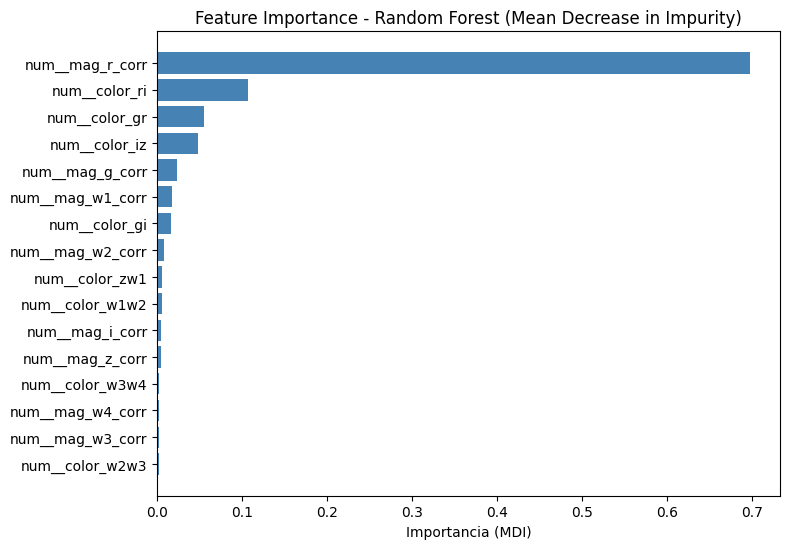

,feature,importance
1,num__mag_r_corr,0.698035
10,num__color_ri,0.106568
9,num__color_gr,0.054737
11,num__color_iz,0.048111
0,num__mag_g_corr,0.022588
4,num__mag_w1_corr,0.017421
8,num__color_gi,0.016609
5,num__mag_w2_corr,0.008035
12,num__color_zw1,0.006058
13,num__color_w1w2,0.005014


In [43]:
# --- Interpretabilidad: Feature Importance (MDI) ---

# Nombres de features tras el preprocesamiento (numéricas + one-hot de "type")
feature_names_out = model_opt.named_steps["preprocessor"].get_feature_names_out()

importances_mdi = model_opt.named_steps["regressor"].feature_importances_

imp_mdi_df = pd.DataFrame({
    "feature": feature_names_out,
    "importance": importances_mdi
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(imp_mdi_df))))
plt.barh(imp_mdi_df["feature"], imp_mdi_df["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importancia (MDI)")
plt.title("Feature Importance - Random Forest (Mean Decrease in Impurity)")
plt.tight_layout()
plt.show()

imp_mdi_df

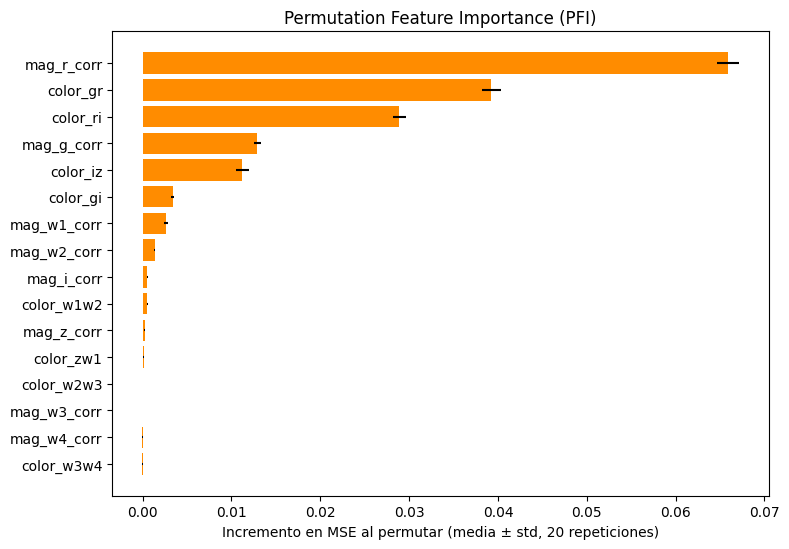

,feature,importance_mean,importance_std
1,mag_r_corr,0.065931,0.001221
9,color_gr,0.039272,0.001078
10,color_ri,0.028911,0.000761
0,mag_g_corr,0.012917,0.000380
11,color_iz,0.011222,0.000706
8,color_gi,0.003381,0.000144
4,mag_w1_corr,0.002623,0.000197
5,mag_w2_corr,0.001338,0.000097
2,mag_i_corr,0.000546,0.000077
13,color_w1w2,0.000543,0.000034


In [44]:
# --- Interpretabilidad: Permutation Feature Importance (PFI) ---
from sklearn.inspection import permutation_importance

# Se calcula sobre el pipeline completo (preprocessor + regressor) y el set de test,
# usando neg_mean_squared_error como métrica base (consistente con la optimización)
pfi_result = permutation_importance(
    model_opt,
    X_test,
    y_test,
    scoring="neg_mean_squared_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

pfi_df = pd.DataFrame({
    "feature": X_test.columns,  # PFI se calcula sobre features de entrada, no las post-OHE
    "importance_mean": pfi_result.importances_mean,
    "importance_std": pfi_result.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(pfi_df))))
plt.barh(
    pfi_df["feature"],
    pfi_df["importance_mean"],
    xerr=pfi_df["importance_std"],
    color="darkorange",
)
plt.gca().invert_yaxis()
plt.xlabel("Incremento en MSE al permutar (media ± std, 20 repeticiones)")
plt.title("Permutation Feature Importance (PFI)")
plt.tight_layout()
plt.show()

pfi_df